# 0.0 데모 — 파이프라인을 눈으로 따라가기

이 노트북은 **이 서브프로젝트의 주된 사용법이 아니다.** 정상 흐름은 CLI 다.

```bash
python3 -m physai.collect  --spec exp/<id>.yaml
python3 -m physai.analyze  --spec exp/<id>.yaml
python3 -m physai.report   --run  <id>
python3 -m physai.verify   --run  <id>
```

여기서는 그 CLI 가 만든 것을 **열어 보며** 무슨 일이 일어났는지 확인한다.
새로 수집하지 않으므로 하드웨어도 긴 시간도 필요 없다.

| 절 | 무엇을 보나 |
|---|---|
| 1 | 실험 명세와 그로부터 유도된 값 (필요 장수·보정 임계) |
| 2 | 데이터셋의 정체 — 스키마·메타데이터·`sample_map` |
| 3 | 누설 벡터 네 성분을 그림으로 |
| 4 | 판정 결과와 **등급 구분** (판정 / 참고 / 양성 대조) |
| 5 | 결함 후보를 **소스 행**까지 되짚기 |
| 6 | 요건 대조표 — 못 지킨 것 |

**먼저 CLI 로 한 번 돌려 두어야 한다.** `runs/<id>/results.json` 이 없으면 아래가 멈춘다.

---
## 1. 실험 명세와 유도된 값

spec 은 **AI 와 도구 사이의 유일한 접점**이다. 판정 기준을 수집 **전에** 적어 두는 것이
핵심이며, 그것이 ISO/IEC 17825 §8.4 `shall [08.04]`(통계 시험 전 파라미터 지정)의 요구다.

필요 장수 N 은 spec 에 적지 않는다 — α·β·d 의 **결과**이지 별도의 판단이 아니기 때문이다.

In [1]:
import sys, json
from pathlib import Path

# 노트북은 demo/ 에 있으므로 프로젝트 루트를 import 경로에 넣는다.
PROJECT = Path.cwd().parent if Path.cwd().name == "demo" else Path.cwd()
sys.path.insert(0, str(PROJECT))

from physai import paths, spec as spec_mod
import sca_schema as S

RUN = "002_emul_masked"   # ← 다른 실험을 보려면 여기만 바꾼다 (001_emul_tinyaes 등)

sp = spec_mod.load(paths.EXP / ("%s.yaml" % RUN))
print("\n".join(spec_mod.summary_lines(sp)))

spec         : 002_emul_masked — 에뮬레이션 — 1차 마스킹 AES 구현의 soundness 검증
IUT          : masked-aes-c (대책: 1st-order Boolean masking (masked-aes-c, CipherMasked 구간만; KeyExpansion 은 비보호)
)
수집기       : emulation
채널         : emulated-power
판정 기준    : Level 3, d=0.04, α=1e-05, β=0.05, bonferroni 보정, |t|>4.5
Formula (1)  : N = 91870 장 필요 (Z_α/2=4.4172, Z_β=1.6449)
전처리       : 평균 1회, 정렬 none
분석         : ta, spa, dpa, soundness, cpa
주장하지 않음:
  - ISO/IEC 19790 적합성 — 모듈 경계·CSP 정의가 이 환경 밖이다
  - 독립 시험소 평가 — 벤더와 시험자가 동일하다(자기시험)
  - 물리 측정 — 이 채널의 값은 측정치가 아니라 누설 모델의 출력이다. 여기서 깨끗해도 실물에서 샐 수 있다
  - 고차(2차 이상) DPA 저항성 — 시험 범위 밖이다
  - EM (SEMA/DEMA) — 근접 자기장 프로브를 보유하지 않는다
  - cycle-accurate 타이밍 — Unicorn 에 사이클 모델이 없어 명령어 수로만 잰다
  - KeyExpansion 의 보호 — 이 구현은 CipherMasked 만 보호하며 키 스케줄은 벤더 원본 비마스킹이다
  - Annex H 민감 경계 확정 — 아래 경계는 제안이며 확정은 사람·승인 기관의 몫이다
Subset       :
  /ta_rk_fp       [timing                  ]    1000 장  키=random 평문=fixed
  /ta_fk_rp       [timing                  ]    1000 장  키=fixed 평문=rando

In [2]:
need = spec_mod.required_n(sp["criteria"])
print("Formula (1) — %s" % need["formula"])
print("  Z_(a/2) = %.4f,  Z_b = %.4f,  d = %s"
      % (need["z_alpha_half"], need["z_beta"], sp["criteria"]["effect_size_d"]))
print("  N = %d 장  (%s)" % (need["n_required"], need["source"]))
print()

ds = paths.TRACES / ("%s.h5" % RUN)
ns = int(S.root_attrs(ds)["samples_per_trace"])
th = spec_mod.corrected_threshold(sp["criteria"], ns)
print("다중비교 보정 (SS8.4 shall [08.03])")
print("  샘플 수 m        = %d" % th["n_tests"])
print("  보정 전 임계     = %.1f" % th["threshold_uncorrected"])
print("  per-test alpha   = %.3g" % th["alpha_per_test"])
print("  보정 후 임계     = %.3f  <- 실제로 쓰는 값" % th["threshold"])
print()
print("보정하지 않으면 귀무가설이 참이어도 수만 개 샘플 중 수십 개가 우연히 4.5 를 넘는다.")

Formula (1) — N = 4 (Z_{alpha/2} + Z_beta)^2 / d^2
  Z_(a/2) = 4.4172,  Z_b = 1.6449,  d = 0.04
  N = 91870 장  (ISO/IEC 17825:2024 Formula (1))

다중비교 보정 (SS8.4 shall [08.03])
  샘플 수 m        = 40588
  보정 전 임계     = 4.5
  per-test alpha   = 2.46e-10
  보정 후 임계     = 6.329  <- 실제로 쓰는 값

보정하지 않으면 귀무가설이 참이어도 수만 개 샘플 중 수십 개가 우연히 4.5 를 넘는다.


---
## 2. 데이터셋의 정체

에뮬레이션 트레이스의 값은 **측정치가 아니라 누설 모델의 출력**이다. 그래서 스키마가
`leakage_model`·`build_flags`·`binary_sha256` 을 필수로 요구한다 — 모델과 빌드를 모르면
"샌다/안 샌다" 가 무슨 뜻인지 알 수 없고 재현도 불가능하다.

`sample_axis=instruction` 이므로 **`sample_rate_hz` 는 존재하지 않는다.** 없는 값을
지어내지 않는 대신 축의 정체를 명시한다.

In [3]:
bad = S.validate_dataset(path=ds)
print("스키마 준수:", "예" if not bad else "위반 %d건" % len(bad))
for b in bad:
    print("   -", b)
print()

a = S.root_attrs(ds)
for k in ("schema_version", "channel_type", "sample_axis", "samples_per_trace",
          "leakage_model", "leakage_segments", "emulator", "instruction_set",
          "build_flags", "binary_sha256", "window_symbols",
          "exec_time_unit", "exec_time_epsilon", "preprocessing_average_n",
          "trigger_semantics"):
    v = str(a.get(k, "(없음)"))
    print("  %-24s %s" % (k, v if len(v) < 96 else v[:93] + "..."))
print()
for name in S.subset_names(ds):
    print("  /%-12s %6d 레코드" % (name, S.group_len(ds, name)))

스키마 준수: 예

  schema_version           1.1
  channel_type             emulated-power
  sample_axis              instruction
  samples_per_trace        40588
  leakage_model            concat(HW(reg), HD(reg,same), HW(mem), HD(mem,same))
  leakage_segments         hw_reg:0-10147,hd_reg:10147-20294,hw_mem:20294-30441,hd_mem:30441-40588
  emulator                 unicorn 2.1.4
  instruction_set          ARMv7-M Thumb
  build_flags              -mcpu=cortex-m4 -mthumb -mfloat-abi=soft -Os -funsigned-char -funsigned-bitfields -fshort-enu...
  binary_sha256            4c1c936f8808d7aecdac29b80f0d4dc7d620ed55e432b0ea4bb6a0a86a7302f8
  window_symbols           AES_init_ctx:0x822c,AES_ECB_encrypt:0x8298
  exec_time_unit           instruction
  exec_time_epsilon        1.0
  preprocessing_average_n  1
  trigger_semantics        AES_init_ctx(KeyExpansion) 진입부터 AES_ECB_encrypt 복귀까지. 실측 펌웨어의 MY_AES_ECB 트리거와 같은 구간이라 두 채널을 나...

  /attack         2000 레코드
  /profiling      4000 레코드
  /spa_diffkey     

In [4]:
# sample_map — 샘플을 명령어로 되짚는 표. 이것이 없으면 "샌다" 까지만 말할 수 있고
# "여기서 샌다" 를 말할 수 없다.
smap = S.load_sample_map(ds)
print("sample_map shape:", smap.shape, "  열 = (segment_id, instruction_index, address)")
print()
segs = [s.split(":") for s in str(a["leakage_segments"]).split(",")]
for i, (nm, rng) in enumerate(segs):
    lo, hi = rng.split("-")
    print("  segment %d  %-8s 샘플 %s..%s" % (i, nm, lo, hi))
print()
print("예: 샘플 1500 은 ->", dict(zip(("segment", "instruction", "address"),
                                     (int(smap[1500][0]), int(smap[1500][1]), hex(smap[1500][2])))))

sample_map shape: (40588, 3)   열 = (segment_id, instruction_index, address)

  segment 0  hw_reg   샘플 0..10147
  segment 1  hd_reg   샘플 10147..20294
  segment 2  hw_mem   샘플 20294..30441
  segment 3  hd_mem   샘플 30441..40588

예: 샘플 1500 은 -> {'segment': 0, 'instruction': 1500, 'address': '0x8378'}


---
## 3. 누설 벡터 네 성분

```
trace = [ hw_reg | hd_reg | hw_mem | hd_mem ]
```

**HD 는 같은 저장소(레지스터·메모리 주소)의 한 명령어 앞뒤 값끼리만** 계산한다.
서로 다른 레지스터 쌍은 실제 하드웨어에서 전이 누설이 생기는 방식이 아니고,
조합이 폭발해 오탐만 만든다.

`hd_reg`·`hd_mem` 이 이 프로젝트의 표적이다 — 같은 레지스터에 두 share 가 연달아 실리면
`HD = HW(share1 ^ share2) = HW(민감값)` 이 되어, **수식은 그대로인데 구현만 새는** 상태가 된다.

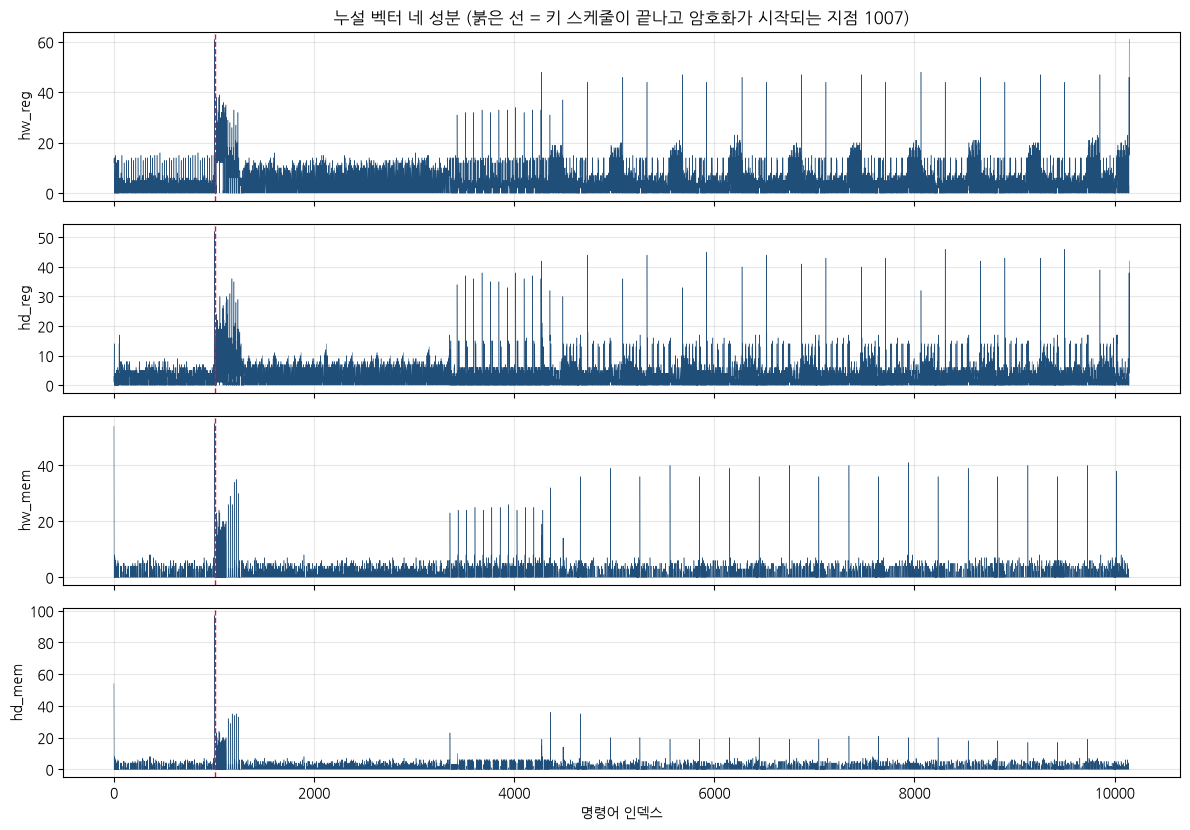

실행시간(exec_time) = [10147, 10147] 명령어
-> 두 트레이스의 실행시간이 같으면 제어흐름이 데이터에 의존하지 않는다는 뜻이다.
   다만 Unicorn 에는 사이클 모델이 없으므로 constant-time 이 증명된 것은 아니다.


In [5]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
try:
    matplotlib.rcParams["font.family"] = "NanumGothic"
    matplotlib.rcParams["axes.unicode_minus"] = False
except Exception:
    pass

g = S.load_group(ds, "profiling", n=2, fields=[S.F_TRACE, S.F_EXEC_TIME])
tr = g[S.F_TRACE][0]
L = int(a["samples_per_trace"]) // len(segs)
enc = dict(p.split(":") for p in str(a["window_symbols"]).split(","))
enc_addr = int(enc["AES_ECB_encrypt"], 16)
seg0 = smap[smap[:, 0] == 0]
enc_start = int(seg0[seg0[:, 2] == enc_addr][0][1])

fig, axes = plt.subplots(len(segs), 1, figsize=(12, 2.1 * len(segs)), sharex=True)
for i, (nm, _) in enumerate(segs):
    axes[i].plot(tr[i * L:(i + 1) * L], lw=0.35, color="#1f4e79")
    axes[i].axvline(enc_start, color="crimson", lw=1.0, ls="--")
    axes[i].set_ylabel(nm)
    axes[i].grid(alpha=0.3)
axes[-1].set_xlabel("명령어 인덱스")
axes[0].set_title("누설 벡터 네 성분 (붉은 선 = 키 스케줄이 끝나고 암호화가 시작되는 지점 %d)"
                  % enc_start)
fig.tight_layout(); plt.show()

print("실행시간(exec_time) =", g[S.F_EXEC_TIME].tolist(), "명령어")
print("-> 두 트레이스의 실행시간이 같으면 제어흐름이 데이터에 의존하지 않는다는 뜻이다.")
print("   다만 Unicorn 에는 사이클 모델이 없으므로 constant-time 이 증명된 것은 아니다.")

---
## 4. 판정 결과 — 등급을 먼저 본다

`results.json` 의 `grades` 가 **무엇이 판정이고 무엇이 참고인지** 명시한다.
이 구분이 없으면 참고 수치로 합/부를 주장하게 된다.

| 등급 | 항목 |
|---|---|
| `mandatory` | ta · spa · dpa — §7.3.2 `shall [07.03]` 이 셋 모두를 요구한다 |
| `judgement` | soundness |
| `reference_only` | snr — **합/부를 주장하지 않는다** |
| `positive_control` | cpa — 배관 검증. 표준상 필수 시험이 아니다 |

In [6]:
res = json.loads((paths.run_dir(RUN) / "results.json").read_text(encoding="utf-8"))
print("등급:", json.dumps(res["grades"], ensure_ascii=False))
print()
for k, v in res["tests"].items():
    print("  %-10s %-14s %s" % (k, v.get("verdict"), (v.get("reason") or "")[:88]))
print()
cpa = res.get("reference", {}).get("cpa")
if cpa:
    print("양성 대조 CPA: %d/16 바이트 복구, 평균 순위 %.1f  (판정 아님)"
          % (cpa["bytes_recovered"], cpa["mean_rank"]))
    print("  -> 16/16 이면 입력 주입·정렬·라벨링 배관이 정상이라는 뜻이다.")
    print("     이 대조가 실패하면 데이터가 아니라 도구를 먼저 의심한다.")

등급: {"mandatory": ["ta", "spa", "dpa"], "judgement": ["soundness"], "reference_only": ["snr"], "positive_control": ["cpa"]}

  ta         pass           
  spa        inconclusive   
  dpa        inconclusive   장수 부족 — 보유 4000장(=2000+2000), Formula (1) 요구 91870장. 검정력이 모자라 '누설 없음' 을 주장할 수 없다.
  soundness  fail           

양성 대조 CPA: 1/16 바이트 복구, 평균 순위 132.9  (판정 아님)
  -> 16/16 이면 입력 주입·정렬·라벨링 배관이 정상이라는 뜻이다.
     이 대조가 실패하면 데이터가 아니라 도구를 먼저 의심한다.


### `inconclusive` 를 `pass` 로 옮기지 않는다

장수가 Formula (1) 요구에 못 미치면 DPA 는 `inconclusive` 다. 검정력이 모자라
"누설 없음" 을 **주장할 수 없기** 때문이지 안전하다는 뜻이 아니다.

반대로 **누설이 관측되었다면 그 사실은 장수와 무관하게 유효하다** — 관측된 것은 관측된 것이다.

---
## 5. 결함 후보를 소스 행까지 되짚기

이것이 에뮬레이션 채널의 존재 이유다. "샌다" 가 아니라 **"이 명령어에서 샌다"** 여야
고칠 수 있다. 하네스를 `-gdwarf-2` 로 빌드했으므로 `addr2line` 이 소스 행을 준다.

In [7]:
import subprocess
from collections import Counter

snd = res["tests"].get("soundness", {})
cands = [c for c in snd.get("candidates", []) if c["in_sensitive_window"]]
print("민감 경계 안 결함 후보: %d개" % len(cands))

if cands:
    elf = paths.HARNESS_BUILD / ("%s.elf" % sp["iut"]["name"])
    top = Counter((c["address"], c["component"]) for c in cands).most_common(8)
    print("\n가장 자주 검출된 (주소, 성분):\n")
    for (addr, comp), cnt in top:
        try:
            line = subprocess.run(["arm-none-eabi-addr2line", "-f", "-e", str(elf), addr],
                                  capture_output=True, text=True, timeout=10).stdout.split("\n")
            where = "%s  @ %s" % (line[0], line[1].split("/")[-1])
        except Exception as e:
            where = "(addr2line 실패: %s)" % e
        print("  %-8s %-8s x%-4d  %s" % (addr, comp, cnt, where))
    print("\n검출된 성분 분포:", dict(Counter(c["component"] for c in cands)))
else:
    print("\n검출 없음. 다만 이 결과는 **같은 검출기가 비마스킹 구현에서 반응한다는")
    print("증거(exp/001_emul_tinyaes)가 있어야만** 의미를 갖는다.")

민감 경계 안 결함 후보: 281개

가장 자주 검출된 (주소, 성분):

  0x8270   hw_reg   x8     KeyExpansion  @ aes.c:488
  0x8276   hw_reg   x8     KeyExpansion  @ aes.c:489
  0x827a   hw_reg   x8     KeyExpansion  @ aes.c:490
  0x8280   hw_reg   x8     KeyExpansion  @ aes.c:491
  0x81be   hw_reg   x8     remask  @ aes.c:282 (discriminator 3)
  0x81c4   hw_reg   x8     remask  @ aes.c:283 (discriminator 3)
  0x81ca   hw_reg   x8     remask  @ aes.c:284 (discriminator 3)
  0x81d0   hw_reg   x8     remask  @ aes.c:285 (discriminator 3)

검출된 성분 분포: {'hd_reg': 67, 'hw_reg': 134, 'hw_mem': 40, 'hd_mem': 40}


---
## 6. 요건 대조표 — 못 지킨 것을 본다

자동화 환경의 가장 큰 위험은 **준수한 척하는 보고서**다. 도구가 돌고 숫자가 나오면
그것이 곧 적합성 판정처럼 읽힌다. 대조표는 반대로 **못 지킨 것을 먼저 드러낸다.**

`미기록`(모른다)과 `미준수`(안 지켰다)는 다르다. `범위밖`은 이 환경이 **원리적으로**
판정할 수 없는 항목이다 — 독립 시험소, 승인 기관, 육안 검사.

In [8]:
from physai import conformance

rep = conformance.check(dataset_path=ds, spec=sp, results=res,
                        level=sp["criteria"]["security_level"])
print("집계:", rep["tally"])
print()
print("주장하지 않는 것:")
for s in rep["not_claimed"]:
    print("  -", s)
print()
print("준수하지 못했거나 판정할 수 없는 항목:")
for it in rep["items"]:
    if it["verdict"] in ("미준수", "미기록"):
        print("  [%s] %-42s %s" % (it["verdict"], it["clause"], it["evidence"][:70]))

집계: {'범위밖': 5, '해당없음': 8, '준수': 15, '미기록': 3, '미준수': 2}

주장하지 않는 것:
  - ISO/IEC 19790 적합성 — 모듈 경계·CSP 정의가 이 환경 밖이다
  - 독립 시험소 평가 — 벤더와 시험자가 동일하다(자기시험)
  - 물리 측정 — 이 채널의 값은 측정치가 아니라 누설 모델의 출력이다. 여기서 깨끗해도 실물에서 샐 수 있다
  - 고차(2차 이상) DPA 저항성 — 시험 범위 밖이다
  - EM (SEMA/DEMA) — 근접 자기장 프로브를 보유하지 않는다
  - cycle-accurate 타이밍 — Unicorn 에 사이클 모델이 없어 명령어 수로만 잰다
  - KeyExpansion 의 보호 — 이 구현은 CipherMasked 만 보호하며 키 스케줄은 벤더 원본 비마스킹이다
  - Annex H 민감 경계 확정 — 아래 경계는 제안이며 확정은 사람·승인 기관의 몫이다

준수하지 못했거나 판정할 수 없는 항목:
  [미기록] §7.3.5 · §8.3.1                            
  [미기록] §8.4 `shall [08.02]`                       장수 부족 — 보유 4000장(=2000+2000), Formula (1) 요구 91870장. 검정력이 모자라 '누설 없음' 
  [미기록] §8.2 (Reference [50])                      
  [미준수] A.2.3 · Formula (1)                        요구 91870장, 보유 4000장
  [미준수] A.2.5 `shall [A.01]` · `shall [07.10]`     preprocessing_average_n=1


---
## 정리

| 무엇 | 어디에 |
|---|---|
| 실험 계획 보고서 (**수집 전** 생성) | `runs/<id>/01_experiment_plan.md` |
| 분석 결과 보고서 | `runs/<id>/02_analysis_report.md` |
| 증거 번들 | `runs/<id>/03_evidence_manifest.md` + `manifest.json` |

```bash
python3 -m physai.verify --run <id>    # 해시·스키마·툴체인 대조
```

### 이번에 보지 않은 고리

에뮬레이션은 **구현 층**만 본다. HW/HD 모델은 글리치·커플링 같은 물리 효과를 담지 않으므로
**여기서 깨끗해도 실물에서 샐 수 있다.** 반대로 실측에서 잡음에 묻힌 누설은 여기서 보인다.

세 관측은 대체재가 아니라 **상보재**이고, 어느 하나가 깨끗하다는 사실만으로 안전을
주장할 수 없다. 실물 전력·디버그 트레이스 수집기는 골격만 있고 **실행된 적이 없다.**